# Week 13: Unsupervised Learning
Until now, we’ve focused exclusively on supervised learning—training models with labeled data to make predictions. **But what if we don’t have labeled data?** Imagine you’re analyzing thousands of customer interactions to find anomalies that might indicate fraudulent activity, or you’ve been tasked with organizing a large set of email complaints to present to the marketing team. Without labels to guide you, how can you detect these patterns? 

This week, we’ll explore **unsupervised learning**, which allows us to uncover hidden patterns and group data points, even when no labels are available. We’ll investigate two essential techniques: **clustering**, which groups similar observations together to reveal underlying patterns and **dimensionality reduction**, simplifying high-dimensional data while preserving its essential structure. These methods are key for tasks like customer segmentation, anomaly detection, and data visualization, helping us make sense of complex datasets in new ways.

## Key Terms:
- **Unsupervised Learning:** A type of machine learning that finds patterns in data without labeled outcomes
- **Clustering:** A method of grouping similar data points together based on shared features
- **K-Means Clustering:** A clustering algorithm that partitions data into a specified number of clusters, minimizing variance within clusters
- **Dimensionality Reduction:** Techniques used to reduce the number of features in a dataset while retaining essential information
- **Principal Component Analysis (PCA):** A dimensionality reduction method that transforms data into a smaller number of uncorrelated components, preserving maximum variance

## Learning Objectives
By the end of this week, you will be able to:
- Describe the concept of unsupervised learning and differentiate it from supervised learning
- Identify key applications of unsupervised learning, such as clustering and dimensionality reduction
- Apply clustering techniques such as K-Means and Hierarchical Clustering to group data without labels
- Describe the metrics for evaluating clustering performance, such as the “elbow” method and “silhouette scores”
- Use dendrograms to interpret the clustering relationships in a dataset
- Examine the basic ideas of Principal Components Analysis for reducing the dimensionality of a dataset
- Interpret a 2D visualization of a dataset using PCA

## 13.1 Lesson: Clustering with K-Means
Clustering is a cornerstone of unsupervised learning, offering a powerful way to uncover similarities and differences in a set of data points. It plays a vital role in domains where labeled data is scarce or unavailable, allowing us to segment customers, detect anomalies, or identify patterns in genomic data. Beyond these practical applications, clustering also serves as a tool for simplifying complex datasets, making them easier to visualize and understand. 

**Clustering** is a technique for grouping a set of data points into clusters, where data points in the same cluster are more similar to each other than to those in other clusters. The various algorithms used in cluster analysis derive from the definition of similarity that makes sense in a particular domain,

### K-Means Clustering
The K-Means algorithm attempts to partition a dataset $X = x_1, x_2, \dots, x_n$ of points from $\mathbb{R}^m$ into $k$ clusters $\{C_1, C_2, \dots, C_k \}$ by minimizing the sum of squared distances between data points and their corresponding cluster centroids.

A critical aspect of this algorithm is that the number of clusters $k$ must be fixed in advance. This is a serious limitation, but we shall discuss below ways to choose appropriate $k$. 

### Algorithm Steps:
1. **Initialize:** Select $k$ initial cluster centroids $\mu_1, \mu_2, \dots, \mu_k$ either randomly or by using a heuristic such as k-means++ (discussed below). (Centroids are simply points in $\mathbb{R}^m$ and in general do not coincide with data points)
2. **Assignment Step:** For each data point $x_i$, assign it to the cluster $C_j$ whose centroid $\mu_j$ is closest:
$$ C_j \quad = \quad \{ x_i : \Vert x_i - U_j \Vert^2 \leq \Vert x_i - \mu_p \Vert \forall_p = 1, 2, \dots, k  \}$$

Where $\vert \vert$ denotes the Euclidean distance.
3. **Update Step:** Recalculate the centroid of each cluser as the mean of the points assigned to it:
$$ \mu_j \quad = \quad \frac{1}{\|C_j\|}\sum_{x_i \in C_j}{x_i}$$

where $\|C_j\|$ is the number of points in the cluster $C_j$.

4. **Repeat:** Alternate between the Assignment and Update steps until convergence, typically when the centroids no longer change significantly or a predefined number of iterations is reached.

### How to Evaluate the Results?
K-Means minimizes the Within-Cluster Sum of Squares (WCSS), which measures the compactness of clusters by summing the squared distances between data points and their nearest centroid:
$$WCSS \quad = \quad \sum_{j=1}^k \; \sum_{x_i \in C_j} \; \Vert x_i - \mu_j \Vert^2 $$ 

This metric, also referred to as inertia, decreases as $k$ increases since more clusters lead to smaller, tighter groups. However, simply minimizing WCSS by increasing $k$ can result in overfitting, as in the extreme case of $k \; = \; n$, where each point is its own cluster.

### Convergence
K-Means is guaranteed to converge to a local minimum of WCSS, but the solution depends on the initial centroids. Different initializations can produce varying clusterings, especially when the data lacks clear groupings.

There are two strategies to mitigate this:
1. **K-Means++** improves convergence by selecting well-spread initial centroids. It starts with one random centroid and picks subsequent centroids based on their distance from existing ones, increasing the chance of finding a better local minimum. This is the default method in Scikit-learn’s KMeans, enhancing clustering consistency.
2. Running K-Means over $multiple trials$ with different random initializations and choosing the result with the lowest WCSS reduces the risk of poor outcomes. While less necessary with K-Means++, this approach remains useful for challenging datasets.

### How to choose $K$?
Different $k$ will give different results, some of which may be more natural than others, or may be determined by external factors. Here is an example of the latter case.  

A textile company in New York aims to cut delivery costs by relocating warehouses closer to its 118 distributors. A cost-benefit analysis allows for up to 5 warehouses. A cluster analysis of the distributors’ geographical data yields the following results for 5 warehouses:

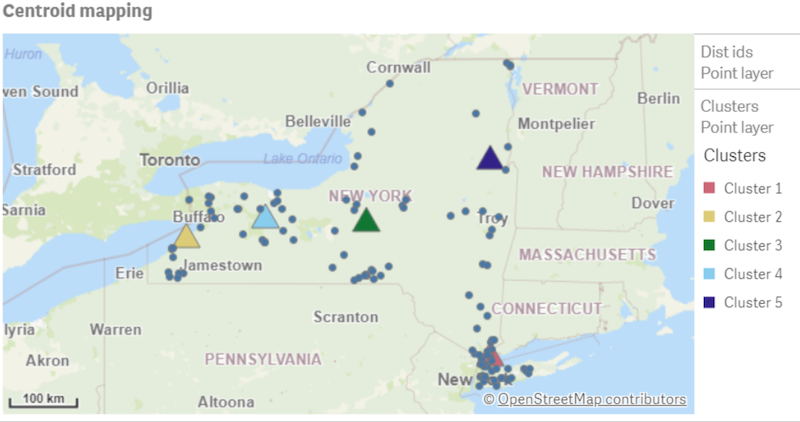

However, in many cases, such as customer segmentation (grouping customers based on behavior, enabling personalized recommendations), you may have no constraints on $k$ and determining the optimal ﻿k﻿ is problematic.

To give a simple example, for the following simple sets of points in 2D:

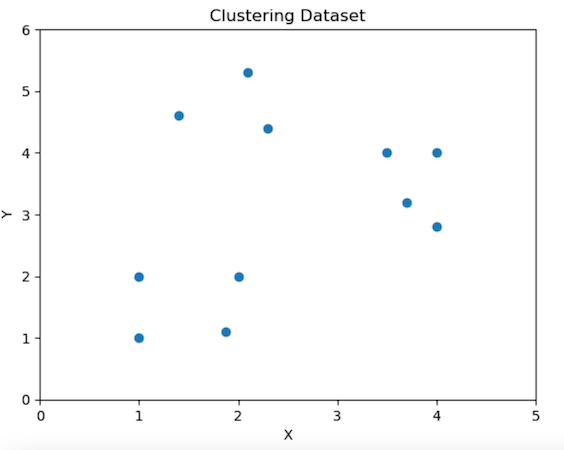

We can see an obvious grouping with $k \; = \; 3$, but the algorithm will gladly go ahead and find groupings for any $k$ from 1 to $n$. Here are four possible choices:

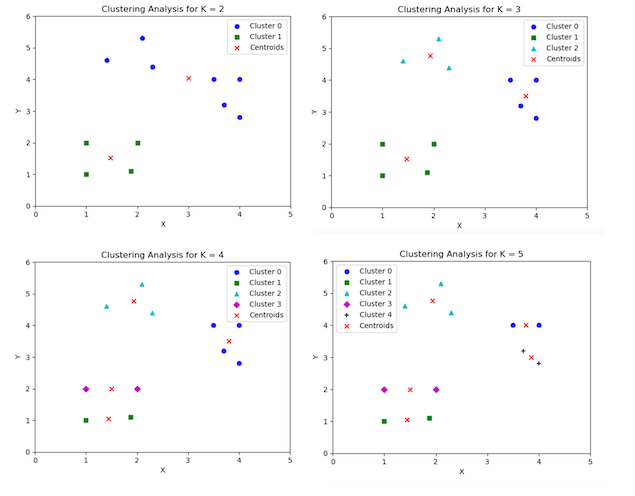

Each plot shows the same data distributed in a two-dimensional space, with X and Y axes ranging from 0 to 5 and 0 to 6, respectively.

Which of these is the most appropriate, given that we have no external constraints on $k$? There are many techniques to address this issue; two of the most intuitive are Elbow Curves and Silhouette Scores.

### Elbow Curves
An Elbow curve is simply a graph of how the WCSS changes as $k$ goes from 1 to $n$:

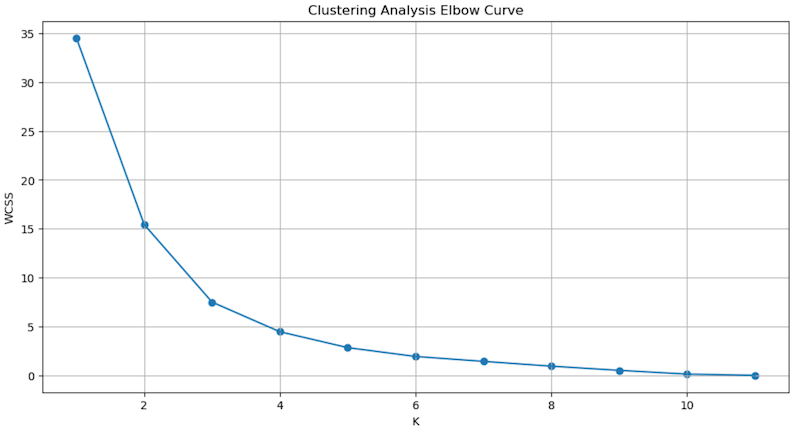

According to this type of analysis, the most natural $k$ occurs at the “elbow” of the curve, the point where the rate of decrease in inertia slows down significantly. This point represents the optimal number of clusters because adding more clusters beyond this does not improve the clustering significantly.

The elbow point reflects a balance between minimizing inertia and keeping the model simple. Here it seems to be $K = 3$, which corresponds to our intuition when viewing the points.

### Silhouette Score
A more quantitative metric is the silhouette score, which measures how well each data point fits within its assigned cluster compared to other clusters. The silhouette score for a data point $x_i$ is in the range $[-1, \dots1]$ and is defined as:
$$ ss(x_i) \quad = \quad \frac{b(i)  - a(i)}{max(a(i), b(i))}$$


where:
- $a_i$ is the average distance between $x_i$ and all other points in the same cluster (cohesion)
- $b_i$ is the average distance between $x_i$ and all points in the nearest neighboring cluster (separation)

The silhouette score for the entire dataset is the average of the silhouette scores for all data points.

Here is the silhouette score for $k=2, \dots, 10$ for our synthetic dataset:

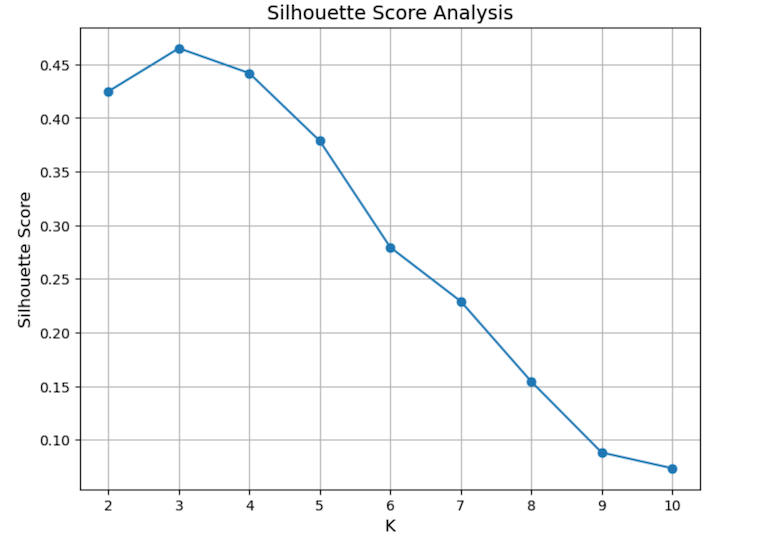

### Think About It
- How do the initialization of centroids and the number of iterations impact the final clustering results? Why might different runs of K-Means produce different clusterings? 
- Why does WCSS always decrease as the number of clusters $k$ increases? 
- Consider the textile company example. Why might external factors, like cost-benefit analyses, influence the choice of $k$ beyond the algorithm’s suggestions? How can clustering results be integrated with business decision-making? 





## 13.2 Lesson: Hierarchical Clustering
Having explored decision trees, you’ll find hierarchical clustering similarly intuitive—it also uses a tree-like structure, but instead of making predictions, it reveals natural groupings within data. Hierarchical clustering builds a hierarchy of clusters, either by starting with individual data points and merging them step by step (agglomerative) or by starting with a single large cluster and splitting it into smaller ones (divisive). Like decision trees, hierarchical clustering simplifies complex data, but here, the focus is on minimizing within-cluster dissimilarity or maximizing between-cluster separation. With no need to predefine the number of clusters ﻿k﻿, hierarchical clustering provides flexibility and works well for datasets with non-spherical clusters, allowing you to uncover data structure at multiple levels of granularity.

### Agglomerative Clustering
For efficiency reasons, the bottom-up approach is more commonly used. Since we have already studied tree-based ML algorithms extensively, we can describe the use of trees succinctly:

### Agglomerative Clustering Algorithm
1. Initialize each data point as its own cluster.
2. Calculate the pairwise distances between all clusters.
3. Merge the two clusters with the **smallest distance** between them.
4. Repeat steps 2 and 3 until all data points belong to a single cluster.
5. [Optional]: Display the result with a dendrogram.

Clearly, the only non-trivial aspect of this algorithm is how we define “distance.” 

### Linkage Criteria (Distance Metrics)
When performing agglomerative clustering, the linkage criterion determines how the distance between clusters is calculated. Here’s a summary of the methods available in `sklearn` to define the distance between two clusters $A$ and $B$, with their pros and cons.

#### Single Linkage: d(A,B) = shortest distance between a point in A and a point in B
- Pro: Can handle irregularly shaped clusters.
- Con: Prone to "chaining," where distant points are linked via intermediate points.

#### Complete Linkage: d(A,B) = greatest distance between a point in A and a point in B
- Pro: Tends to form compact, spherical clusters.  
- Con: Sensitive to outliers.

#### Average Linkage: d(A,B) = average distance between points in A and points in B 
- Pro: Balances compactness and chaining.  
- Con: Computationally more intensive.

#### Ward’s Linkage: d(A,B) = increase in total variance within clusters when merging:
$$d(A,B) \quad = \quad \frac{ |A| + |B|}{N} \Vert \mu_A - \mu_B \Vert^2$$
- Pro: Creates balanced, compact clusters.  
- Con: Assumes clusters are roughly equal in size.

Each criterion has strengths and weaknesses, and the best choice depends on the data and the clustering goals.

### Which Linkage Method is Best?
Unfortunately, the usual answer is “it depends on the data.” The best practice is to try various clustering methods on your dataset and on subsets or bootstrap samples from the data to explore the data and determine the robustness of the clusters obtained.

The following diagram from the `sklearn` documentation compares these methods on several different clustering problems.

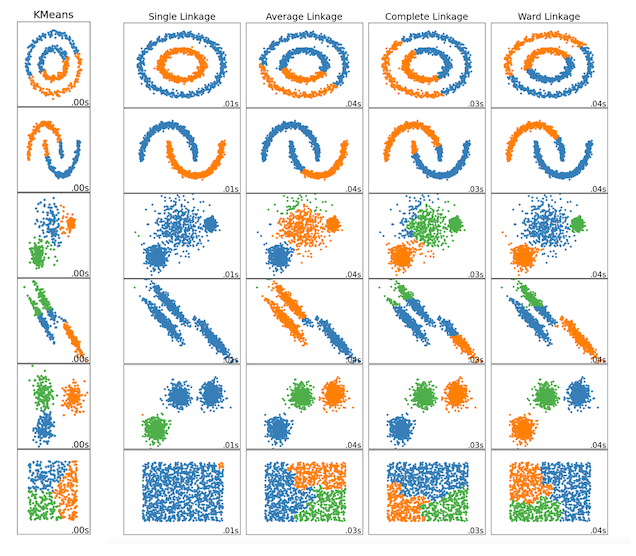

#### Dendrograms
Hierarchical clustering provides a valuable visualization that illustrates how clusters were formed, including the cluster groupings and the distances at which they were merged. Below is our synthetic dataset, along with a scatterplot showing the clusters created using average linkage:

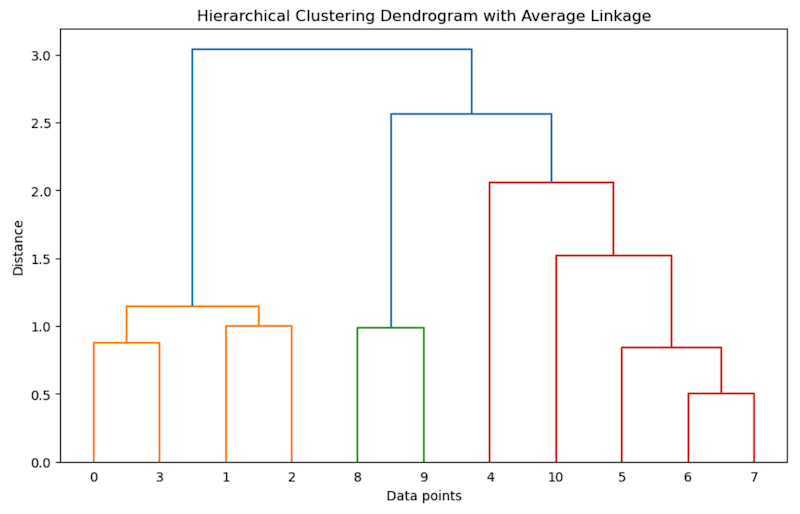

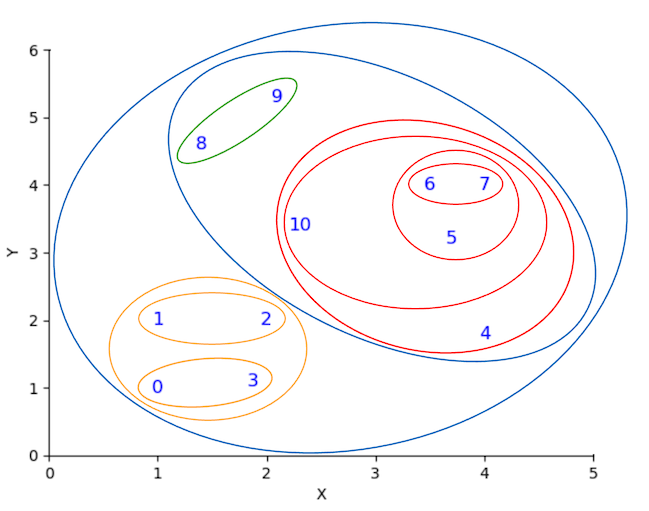

### Conclusion
Hierarchical clustering offers a flexible, intuitive way to explore data, with dendrograms providing insights into cluster relationships without requiring a predefined ﻿k﻿. It works well for small datasets and non-spherical clusters but can be computationally expensive and sensitive to noise. In contrast, K-Means is more efficient for larger datasets and performs well with spherical, balanced clusters but requires specifying ﻿k﻿ upfront and is sensitive to initialization. The choice between these methods depends on the dataset size, cluster shapes, and the need for interpretability.  

### Think About It
- How does hierarchical clustering help uncover data structure at multiple levels of granularity? What insights can dendrograms provide that other clustering methods cannot?
- Why might single linkage clustering result in "chaining," and how could this impact the interpretability of the clusters? What types of datasets might still benefit from single linkage?
- Given a dataset with outliers, which linkage method would you choose, and why? What steps could you take to minimize the impact of outliers on your clustering results?
- How can dendrograms help in determining the number of clusters without specifying $k$ upfront? What specific features of the dendrogram would you look at to decide where to cut it?
- Hierarchical clustering can be computationally expensive for large datasets. In what scenarios might you still prefer it over K-Means, despite its higher cost? How would you manage this trade-off in practice?

## 13.3 Lesson: Dimensionality Reduction Using Principal Components Analysis
In the era of big data, we often deal with datasets containing hundreds or even thousands of features. While more features can provide valuable information, they also introduce challenges such as increased computational cost, model overfitting, and lack of interpretability. Principal Component Analysis (PCA) is a linear dimensionality reduction technique that transforms a dataset into a new coordinate system, where the greatest variance in the data lies along the first principal component, the second greatest variance along the second principal component, and so on. Each principal component is a linear combination of the original features and is orthogonal to the others. By projecting data onto a new set of orthogonal axes, PCA simplifies the dataset, enabling more efficient analysis and visualization without significant loss of information.

### Algorithm
1. **Standardize the Data:** Ensure that all features have a mean of 0 and standard deviation of 1.
2. **Compute the Covariance Matrix:** Measure how features vary with respect to each other.
3. **Calculate Eigenvectors and Eigenvalues:**
    1. Eigenvectors determine the direction of the principal components.
    2. Eigenvalues determine the magnitude of variance captured by each principal component
4. **Sort Eigenvectors:** Order them by their corresponding eigenvalues in descending order.
5. **Project the Data:** Transform the original data onto the subspace spanned by the top $k$ principal components, where $k$ is the desired dimensionality.

Let's consider a small example to see the algorithm in action. Here is a simple synthetic dataset in 2D, with the principal component vectors indicated in red and green:

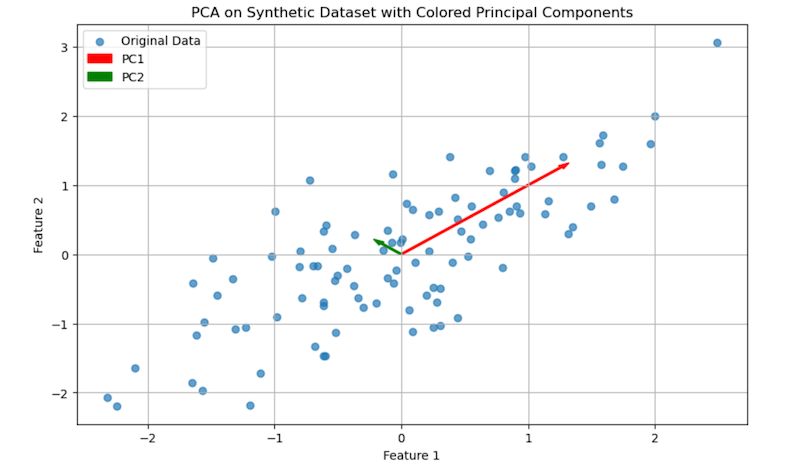

We can reduce to 1D by projecting the points onto the 1D subspace defined by the largest eigenvector (the green lines show that the projection follows the line defined by the smaller eigenvector).

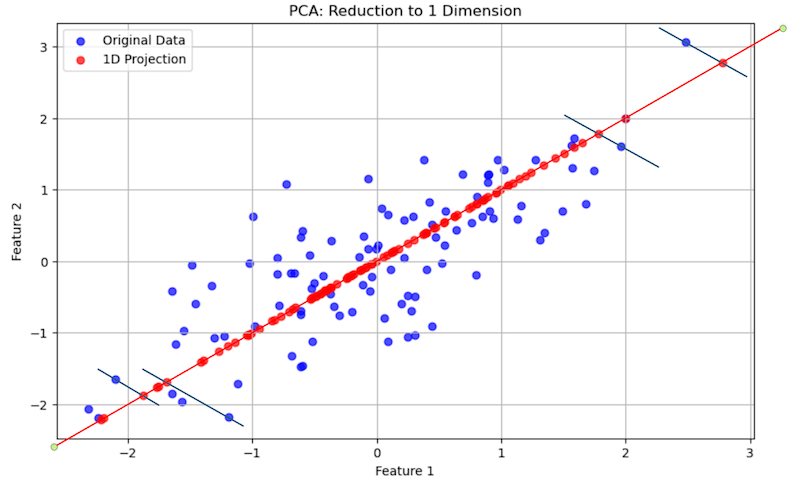

Now the data has only one dimension, but that dimension contains the most variation, and hence the most information.

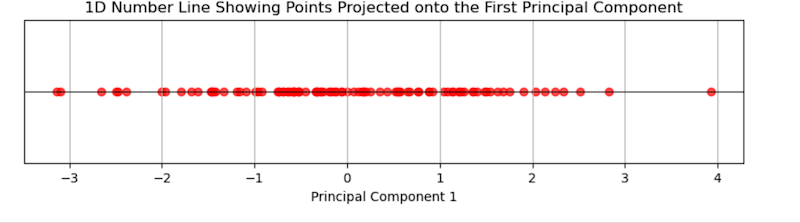

### Three Real World Applications of PCA:
**Data Visualization:** PCA helps visualize high-dimensional datasets in 2D or 3D for exploratory analysis.
Let’s revisit the Week 1 example of Shakespeare’s plays, where a 22,000-dimensional “bag of words” dataset was reduced to 2 dimensions for easier visualization. Plays are color-coded by genre: comedies (green), histories (blue), and tragedies (red), with numbers indicating their order of composition. Clear genre groupings emerge, with some intriguing exceptions: Othello aligns more with comedies, The *Tempest* leans toward tragedies, and *Hamlet* stands apart, perhaps reflecting its thematic and stylistic complexity.

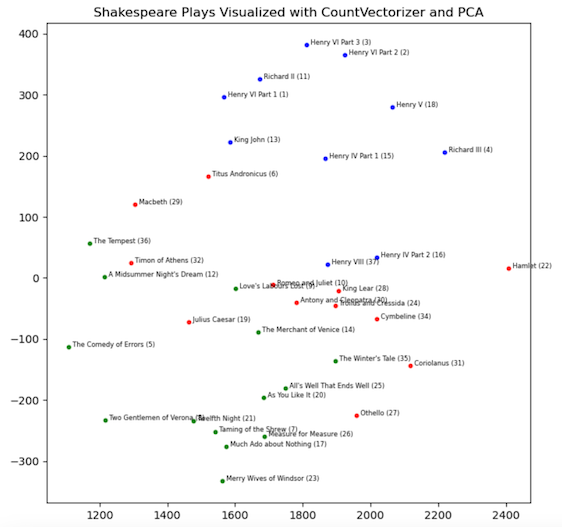

**Image Compression:** PCA reduces the number of features while retaining the most important visual information. To show the power of this technique, here is a simple greyscale image of a boat:

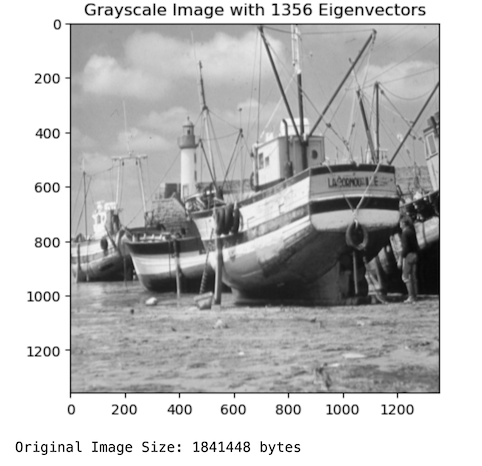

The eigenvalues show that almost all the information is contained in a very small percentage of the 1356 principal components:

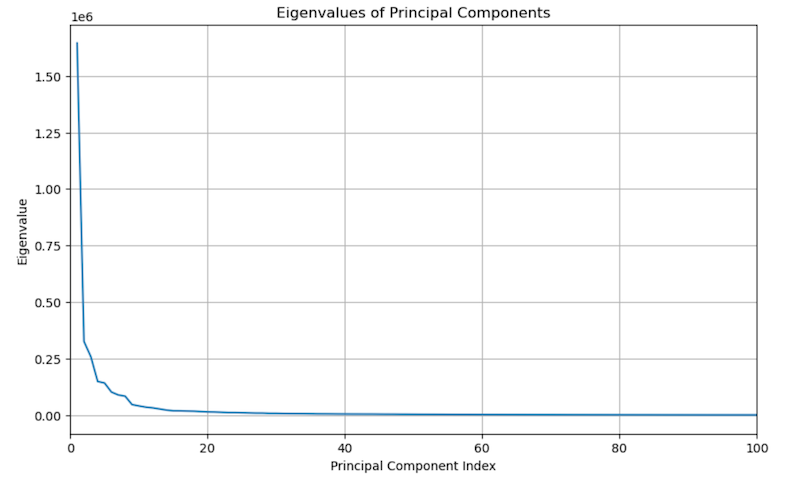

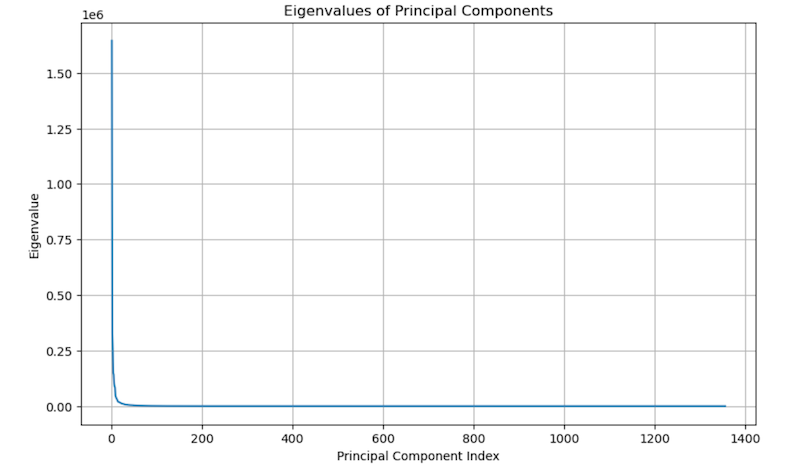

**Here are images formed from 60, 40, 20, and 10 principal components:**

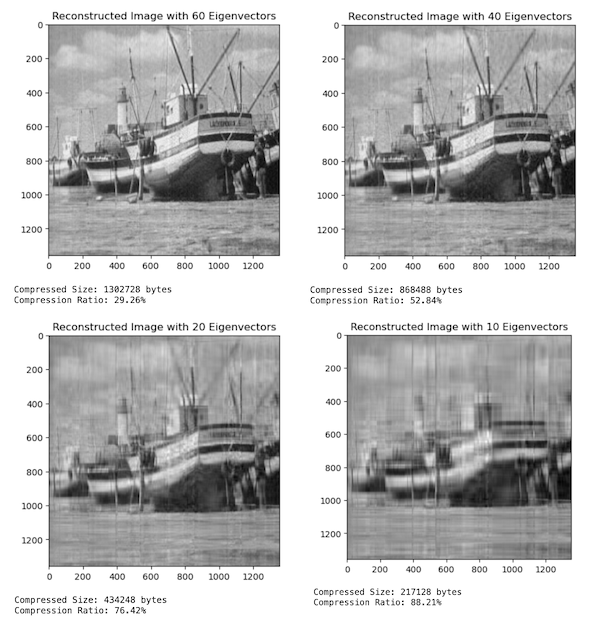

Each image demonstrates the trade-off between compression and visual quality as fewer eigenvectors are used.

**Noise Reduction:** By projecting time series or audio data onto the principal components, PCA can filter out noise, retaining only the most significant patterns.

A good example of this is **Financial Time Series Denoising:** PCA can be applied to stock price data to separate meaningful trends from short-term fluctuations or noise, helping analysts focus on significant market movements. Here is the closing stock price of Tesla from 2015 to 2018, with denoising applied:

### Think About It
- What does it mean for principal components to be "orthogonal" to each other, and why is this important in PCA?
- Why is it necessary to standardize the data before applying PCA?
- How do eigenvalues and eigenvectors relate to the principal components? What does a large eigenvalue signify?
- What other types of noisy data might benefit from PCA denoising?
- How would the performance of PCA change if the dataset contains highly correlated features? 
